In [4]:
# In [1]: Instalar las librerías necesarias (Ejecutar solo una vez)
!pip install requests pandas numpy

# In [2]: Importar las librerías
import requests
import pandas as pd
import numpy as np

# In [3]: Obtener los datos de una URL válida de la API de SpaceX
static_json_url = "https://api.spacexdata.com/v4/launches"  # Nueva URL válida
response = requests.get(static_json_url)

# Imprimir el código de estado y el contenido bruto para inspección
print(f"Status Code: {response.status_code}")
print("Encabezados de la respuesta:")
print(response.headers)
print("\nContenido bruto (primeros 500 caracteres):")
print(response.text[:500])

# Intentar decodificar el contenido como JSON
try:
    data_json = response.json()
    print("\nJSON decodificado exitosamente.")
except requests.exceptions.JSONDecodeError as e:
    print(f"\nError al decodificar JSON: {e}")
    print("El contenido no es un JSON válido. Verifica la URL o el servidor.")
    data_json = None

# Si se decodificó correctamente, convertir a DataFrame
if data_json:
    df = pd.json_normalize(data_json)
    # Mostrar las columnas disponibles en el DataFrame
    print("\nColumnas disponibles en el DataFrame:")
    print(df.columns.tolist())
    # Mostrar las primeras filas del DataFrame para inspeccionar los datos
    print("\nPrimeras filas del DataFrame:")
    df.head()
else:
    print("No se pudo obtener un JSON válido. Revisa la URL o el contenido de la respuesta.")

Status Code: 200
Encabezados de la respuesta:
{'Date': 'Wed, 23 Apr 2025 20:00:20 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Access-Control-Allow-Origin': '*', 'Access-Control-Expose-Headers': 'spacex-api-cache,spacex-api-response-time', 'Alt-Svc': 'h3=":443"; ma=86400', 'Cache-Control': 'max-age=20', 'Content-Encoding': 'gzip', 'Content-Security-Policy': "default-src 'self';base-uri 'self';block-all-mixed-content;font-src 'self' https: data:;frame-ancestors 'self';img-src 'self' data:;object-src 'none';script-src 'self';script-src-attr 'none';style-src 'self' https: 'unsafe-inline';upgrade-insecure-requests", 'Etag': '"6a6b1-nhha/wqddK5vQK/aF0jB2NfjXPg"', 'Expect-Ct': 'max-age=0', 'Referrer-Policy': 'no-referrer', 'Server': 'cloudflare', 'Spacex-Api-Cache': 'MISS', 'Spacex-Api-Cache-Online': 'true', 'Spacex-Api-Response-Time': '102ms', 'Strict-Transport-Security': 'max-age=15552000; includeSubDomains', 'Vary': 

In [5]:
# In [4]: Mostrar las filas del DataFrame en formato vertical
print("Filas del DataFrame en formato vertical:")
df.T

Filas del DataFrame en formato vertical:


,0,1,2,3,4,5,6,7,8,9,...,195,196,197,198,199,200,201,202,203,204
static_fire_date_utc,2006-03-17T00:00:00.000Z,None,None,2008-09-20T00:00:00.000Z,None,2010-03-13T00:00:00.000Z,2010-12-04T00:00:00.000Z,2012-04-30T00:00:00.000Z,2012-09-29T00:00:00.000Z,2013-02-25T18:30:00.000Z,...,None,None,None,None,None,None,None,None,None,None
static_fire_date_unix,1142553600.0,NaN,NaN,1221868800.0,NaN,1268438400.0,1291420800.0,1335744000.0,1348876800.0,1361817000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
net,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
window,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rocket,5e9d0d95eda69955f709d1eb,5e9d0d95eda69955f709d1eb,5e9d0d95eda69955f709d1eb,5e9d0d95eda69955f709d1eb,5e9d0d95eda69955f709d1eb,5e9d0d95eda69973a809d1ec,5e9d0d95eda69973a809d1ec,5e9d0d95eda69973a809d1ec,5e9d0d95eda69973a809d1ec,5e9d0d95eda69973a809d1ec,...,5e9d0d95eda69973a809d1ec,5e9d0d95eda69973a809d1ec,5e9d0d95eda69973a809d1ec,5e9d0d95eda69973a809d1ec,5e9d0d95eda69973a809d1ec,5e9d0d95eda69973a809d1ec,5e9d0d95eda69973a809d1ec,5e9d0d95eda69973a809d1ec,5e9d0d95eda69974db09d1ed,5e9d0d95eda69973a809d1ec
success,False,False,False,True,True,True,True,True,True,True,...,None,None,None,None,None,None,None,None,None,None
failures,"[{'time': 33, 'altitude': None, 'reason': 'mer...","[{'time': 301, 'altitude': 289, 'reason': 'har...","[{'time': 140, 'altitude': 35, 'reason': 'resi...",[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
details,Engine failure at 33 seconds and loss of vehicle,Successful first stage burn and transition to ...,Residual stage 1 thrust led to collision betwe...,Ratsat was carried to orbit on the first succe...,None,None,None,"Launch was scrubbed on first attempt, second l...","CRS-1 successful, but the secondary payload wa...",Last launch of the original Falcon 9 v1.0 laun...,...,None,None,None,None,None,None,None,None,None,None
crew,[],[],[],[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
ships,[],[],[],[],[],[],[5ea6ed2d080df4000697c901],[5ea6ed2d080df4000697c901],[5ea6ed2d080df4000697c902],[5ea6ed2d080df4000697c902],...,[],[],[],[],[],[],[],[],[],[]


In [6]:
# In [1]: Instalar las librerías necesarias (Ejecutar solo una vez)
!pip install requests pandas numpy

# In [2]: Importar las librerías
import requests
import pandas as pd
import numpy as np

# In [3]: Obtener los datos de una URL válida de la API de SpaceX
static_json_url = "https://api.spacexdata.com/v4/launches"
response = requests.get(static_json_url)
data_json = response.json()
df = pd.json_normalize(data_json)

# In [4]: Filtrar filas con un solo core y un solo payload (similar a los screenshots anteriores)
data = df[df['cores'].map(len) == 1]  # Filtrar filas con un solo núcleo
data = data[data['payloads'].map(len) == 1]  # Filtrar filas con un solo payload

# Extraer el primer elemento de las listas
data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])

# In [5]: Convertir la fecha a formato datetime y filtrar antes del 13 de diciembre de 2020
data['date'] = pd.to_datetime(data['date_utc']).dt.date
data = data[data['date'] <= pd.to_datetime('2020-12-13').date()]

# In [6]: Definir funciones para obtener datos adicionales
def getBoosterVersion(data):
    BoosterVersion = []
    for rocket_id in data['rocket']:
        if rocket_id:
            url = f"https://api.spacexdata.com/v4/rockets/{rocket_id}"
            response = requests.get(url)
            BoosterVersion.append(response.json().get('name', 'Unknown') if response.status_code == 200 else 'Unknown')
    return BoosterVersion

def getPayloadData(data):
    PayloadMass = []
    for payload_id in data['payloads']:
        if payload_id:
            url = f"https://api.spacexdata.com/v4/payloads/{payload_id}"
            response = requests.get(url)
            if response.status_code == 200:
                payload_data = response.json()
                PayloadMass.append(payload_data.get('mass_kg', 'Unknown'))
            else:
                PayloadMass.append('Unknown')
        else:
            PayloadMass.append('Unknown')
    return PayloadMass

def getCoreData(data):
    LandingSuccess = []
    LandingType = []
    for core in data['cores']:
        LandingSuccess.append(core.get('landing_success', 'Unknown'))
        LandingType.append(core.get('landing_type', 'Unknown'))
    return LandingSuccess, LandingType

# In [7]: Obtener datos adicionales
BoosterVersion = getBoosterVersion(data)
PayloadMass = getPayloadData(data)
LandingSuccess, LandingType = getCoreData(data)

# In [8]: Crear un nuevo DataFrame con los datos procesados
launch_dict = {
    'BoosterVersion': BoosterVersion,
    'PayloadMass': PayloadMass,
    'LandingSuccess': LandingSuccess,
    'LandingType': LandingType,
    'Date': list(data['date'])
}
data_processed = pd.DataFrame(launch_dict)

# In [9]: Filtrar boosters que aterrizaron exitosamente en un drone ship con payload entre 4000 y 6000 kg
filtered_data = data_processed[
    (data_processed['LandingType'] == 'ASDS') &  # Aterrizaje en drone ship
    (data_processed['LandingSuccess'] == True) &  # Aterrizaje exitoso
    (data_processed['PayloadMass'].apply(lambda x: float(x) if x != 'Unknown' else 0) > 4000) &  # Masa mayor a 4000 kg
    (data_processed['PayloadMass'].apply(lambda x: float(x) if x != 'Unknown' else 0) < 6000)  # Masa menor a 6000 kg
]

# In [10]: Obtener los nombres únicos de los boosters
booster_names = filtered_data['BoosterVersion'].unique().tolist()

# In [11]: Imprimir los resultados con una explicación
print("Boosters que aterrizaron exitosamente en un drone ship con payload entre 4000 y 6000 kg:")
print(booster_names)
print("\nExplicación: Se filtraron los lanzamientos con un solo núcleo y una sola carga útil antes del 13 de diciembre de 2020. Luego, se seleccionaron aquellos que aterrizaron exitosamente en un drone ship (LandingType = 'ASDS' y LandingSuccess = True) y cuya masa de carga útil está entre 4000 y 6000 kg, utilizando los datos obtenidos de la API de SpaceX para boosters y payloads.")

Boosters que aterrizaron exitosamente en un drone ship con payload entre 4000 y 6000 kg:
['Falcon 9']

Explicación: Se filtraron los lanzamientos con un solo núcleo y una sola carga útil antes del 13 de diciembre de 2020. Luego, se seleccionaron aquellos que aterrizaron exitosamente en un drone ship (LandingType = 'ASDS' y LandingSuccess = True) y cuya masa de carga útil está entre 4000 y 6000 kg, utilizando los datos obtenidos de la API de SpaceX para boosters y payloads.


In [8]:
# In [1]: Install required libraries (Run this cell only once)
!pip install requests pandas numpy

# In [2]: Import libraries
import requests
import pandas as pd
import numpy as np

# In [3]: Fetch data from the SpaceX API
static_json_url = "https://api.spacexdata.com/v4/launches"
response = requests.get(static_json_url)
data_json = response.json()
df = pd.json_normalize(data_json)

# In [4]: Filter rows with a single core and a single payload
data = df[df['cores'].map(len) == 1]  # Filter rows with a single core
data = data[data['payloads'].map(len) == 1]  # Filter rows with a single payload

# Extract the first element from the lists
data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])

# In [5]: Define functions to fetch additional data
def getBoosterVersion(data):
    BoosterVersion = []
    for rocket_id in data['rocket']:
        if rocket_id:
            url = f"https://api.spacexdata.com/v4/rockets/{rocket_id}"
            response = requests.get(url)
            BoosterVersion.append(response.json().get('name', 'Unknown') if response.status_code == 200 else 'Unknown')
    return BoosterVersion

def getPayloadData(data):
    PayloadMass = []
    for payload_id in data['payloads']:
        if payload_id:
            url = f"https://api.spacexdata.com/v4/payloads/{payload_id}"
            response = requests.get(url)
            if response.status_code == 200:
                payload_data = response.json()
                PayloadMass.append(payload_data.get('mass_kg', 'Unknown'))
            else:
                PayloadMass.append('Unknown')
        else:
            PayloadMass.append('Unknown')
    return PayloadMass

def getCoreData(data):
    LandingSuccess = []
    LandingType = []
    for core in data['cores']:
        LandingSuccess.append(core.get('landing_success', 'Unknown'))
        LandingType.append(core.get('landing_type', 'Unknown'))
    return LandingSuccess, LandingType

# In [6]: Fetch additional data
BoosterVersion = getBoosterVersion(data)
PayloadMass = getPayloadData(data)
LandingSuccess, LandingType = getCoreData(data)

# In [7]: Create a new DataFrame with the processed data
launch_dict = {
    'BoosterVersion': BoosterVersion,
    'PayloadMass': PayloadMass,
    'LandingSuccess': LandingSuccess,
    'LandingType': LandingType
}
data_processed = pd.DataFrame(launch_dict)

# In [8]: Filter boosters that successfully landed on a drone ship with payload between 4000 and 6000 kg
filtered_data = data_processed[
    (data_processed['LandingType'] == 'ASDS') &  # Landing on drone ship
    (data_processed['LandingSuccess'] == True) &  # Successful landing
    (data_processed['PayloadMass'].apply(lambda x: float(x) if x != 'Unknown' else 0) > 4000) &  # Payload mass greater than 4000 kg
    (data_processed['PayloadMass'].apply(lambda x: float(x) if x != 'Unknown' else 0) < 6000)  # Payload mass less than 6000 kg
]

# In [9]: Inspect the filtered launches
print("Launches meeting the criteria:")
print(filtered_data)

# In [10]: Get the unique names of the boosters
booster_names = filtered_data['BoosterVersion'].unique().tolist()

# In [11]: Print the results with an explanation
print("\nBoosters that successfully landed on a drone ship with payload between 4000 and 6000 kg:")
print(booster_names)
print("\nExplanation: The launches were filtered to include only those with a single core and a single payload. Then, those that successfully landed on a drone ship (LandingType = 'ASDS' and LandingSuccess = True) and had a payload mass between 4000 and 6000 kg were selected, using data retrieved from the SpaceX API for boosters and payloads.")

Launches meeting the criteria:
   BoosterVersion  PayloadMass LandingSuccess LandingType
24       Falcon 9       4696.0           True        ASDS
27       Falcon 9       4600.0           True        ASDS
32       Falcon 9       5300.0           True        ASDS
43       Falcon 9       5200.0           True        ASDS
58       Falcon 9       5800.0           True        ASDS
73       Falcon 9       5000.0           True        ASDS

Boosters that successfully landed on a drone ship with payload between 4000 and 6000 kg:
['Falcon 9']

Explanation: The launches were filtered to include only those with a single core and a single payload. Then, those that successfully landed on a drone ship (LandingType = 'ASDS' and LandingSuccess = True) and had a payload mass between 4000 and 6000 kg were selected, using data retrieved from the SpaceX API for boosters and payloads.


In [9]:
# In [12]: Calculate the total number of successful and failed mission outcomes
success_counts = df['success'].value_counts()

# In [13]: Print the results with an explanation
print("Total number of successful and failed mission outcomes:")
print(f"Successful missions: {success_counts.get(True, 0)}")
print(f"Failed missions: {success_counts.get(False, 0)}")
print("\nExplanation: The 'success' column in the SpaceX dataset was used to count the number of missions. A value of 'True' indicates a successful mission, while 'False' indicates a failed mission. The counts were obtained using pandas' value_counts() method.")

Total number of successful and failed mission outcomes:
Successful missions: 181
Failed missions: 5

Explanation: The 'success' column in the SpaceX dataset was used to count the number of missions. A value of 'True' indicates a successful mission, while 'False' indicates a failed mission. The counts were obtained using pandas' value_counts() method.


In [10]:
# In [14]: Reuse the DataFrame 'data' from previous steps (single core and single payload filtered)
# If not already defined, ensure you have 'data' from earlier steps:
# data = df[df['cores'].map(len) == 1]
# data = data[data['payloads'].map(len) == 1]
# data['cores'] = data['cores'].map(lambda x: x[0])
# data['payloads'] = data['payloads'].map(lambda x: x[0])

# In [15]: Fetch booster names and payload masses (if not already done)
BoosterVersion = getBoosterVersion(data)  # Function already defined
PayloadMass = getPayloadData(data)        # Function already defined

# In [16]: Create a DataFrame with booster names and payload masses
payload_data = pd.DataFrame({
    'BoosterVersion': BoosterVersion,
    'PayloadMass': PayloadMass
})

# In [17]: Convert PayloadMass to numeric, handling 'Unknown' values
payload_data['PayloadMass'] = payload_data['PayloadMass'].apply(lambda x: float(x) if x != 'Unknown' else 0)

# In [18]: Find the maximum payload mass
max_payload = payload_data['PayloadMass'].max()

# In [19]: Filter launches with the maximum payload mass
max_payload_launches = payload_data[payload_data['PayloadMass'] == max_payload]

# In [20]: Get the unique booster names for the maximum payload mass
booster_names_max_payload = max_payload_launches['BoosterVersion'].unique().tolist()

# In [21]: Print the results with an explanation
print(f"Maximum payload mass carried: {max_payload} kg")
print("Boosters that carried the maximum payload mass:")
print(booster_names_max_payload)
print("\nExplanation: The payload masses were retrieved from the SpaceX API using the payload IDs. The maximum payload mass was identified, and the launches carrying this mass were filtered. The corresponding booster names were then extracted, showing which boosters carried the heaviest payload.")

Maximum payload mass carried: 15600.0 kg
Boosters that carried the maximum payload mass:
['Falcon 9']

Explanation: The payload masses were retrieved from the SpaceX API using the payload IDs. The maximum payload mass was identified, and the launches carrying this mass were filtered. The corresponding booster names were then extracted, showing which boosters carried the heaviest payload.


In [12]:
# In [1]: Install required libraries (Run this cell only once)
!pip install requests pandas numpy

# In [2]: Import libraries
import requests
import pandas as pd
import numpy as np

# In [3]: Fetch data from the SpaceX API
static_json_url = "https://api.spacexdata.com/v4/launches"
response = requests.get(static_json_url)
data_json = response.json()
df = pd.json_normalize(data_json)

# In [4]: Filter rows with a single core and a single payload
data = df[df['cores'].map(len) == 1]  # Filter rows with a single core
data = data[data['payloads'].map(len) == 1]  # Filter rows with a single payload

# Extract the first element from the lists
data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])

# In [5]: Define functions to fetch additional data
def getBoosterVersion(data):
    BoosterVersion = []
    for rocket_id in data['rocket']:
        if rocket_id:
            url = f"https://api.spacexdata.com/v4/rockets/{rocket_id}"
            response = requests.get(url)
            BoosterVersion.append(response.json().get('name', 'Unknown') if response.status_code == 200 else 'Unknown')
    return BoosterVersion

def getPayloadData(data):
    PayloadMass = []
    for payload_id in data['payloads']:
        if payload_id:
            url = f"https://api.spacexdata.com/v4/payloads/{payload_id}"
            response = requests.get(url)
            if response.status_code == 200:
                payload_data = response.json()
                PayloadMass.append(payload_data.get('mass_kg', 'Unknown'))
            else:
                PayloadMass.append('Unknown')
        else:
            PayloadMass.append('Unknown')
    return PayloadMass

def getCoreData(data):
    LandingSuccess = []
    LandingType = []
    for core in data['cores']:
        LandingSuccess.append(core.get('landing_success', 'Unknown'))
        LandingType.append(core.get('landing_type', 'Unknown'))
    return LandingSuccess, LandingType

# In [6]: Fetch additional data
BoosterVersion = getBoosterVersion(data)
PayloadMass = getPayloadData(data)
LandingSuccess, LandingType = getCoreData(data)

# In [7]: Create a new DataFrame with the processed data
launch_dict = {
    'BoosterVersion': BoosterVersion,
    'PayloadMass': PayloadMass,
    'LandingSuccess': LandingSuccess,
    'LandingType': LandingType
}
data_processed = pd.DataFrame(launch_dict)

# In [8]: Inspect intermediate results
print("Total launches after initial filtering (single core and payload):", len(data_processed))
print("Launches with LandingType = 'ASDS':", len(data_processed[data_processed['LandingType'] == 'ASDS']))
print("Launches with LandingSuccess = True:", len(data_processed[data_processed['LandingSuccess'] == True]))
print("Launches with PayloadMass between 4000 and 6000 kg:")
payload_mass_filtered = data_processed[
    data_processed['PayloadMass'].apply(lambda x: float(x) if x != 'Unknown' else 0).between(4000, 6000)
]
print(len(payload_mass_filtered))
print(payload_mass_filtered[['BoosterVersion', 'PayloadMass', 'LandingSuccess', 'LandingType']])

# In [9]: Filter boosters that successfully landed on a drone ship with payload between 4000 and 6000 kg
filtered_data = data_processed[
    (data_processed['LandingType'] == 'ASDS') &
    (data_processed['LandingSuccess'] == True) &
    (data_processed['PayloadMass'].apply(lambda x: float(x) if x != 'Unknown' else 0).between(4000, 6000))
]

# In [10]: Inspect the filtered launches
print("Launches meeting all criteria:")
print(filtered_data)

# In [11]: Get the unique names of the boosters
booster_names = filtered_data['BoosterVersion'].unique().tolist()

# In [12]: Print the results with an explanation
print("\nBoosters that successfully landed on a drone ship with payload between 4000 and 6000 kg:")
print(booster_names)
print("\nExplanation: The launches were filtered to include only those with a single core and a single payload. Then, those that successfully landed on a drone ship (LandingType = 'ASDS' and LandingSuccess = True) and had a payload mass between 4000 and 6000 kg were selected, using data retrieved from the SpaceX API for boosters and payloads.")

Total launches after initial filtering (single core and payload): 177
Launches with LandingType = 'ASDS': 118
Launches with LandingSuccess = True: 137
Launches with PayloadMass between 4000 and 6000 kg:
19
    BoosterVersion  PayloadMass LandingSuccess LandingType
12        Falcon 9      4535.00           None        None
13        Falcon 9      4428.00           None        None
18        Falcon 9      4707.00           None        None
22        Falcon 9      5271.00          False        ASDS
24        Falcon 9      4696.00           True        ASDS
27        Falcon 9      4600.00           True        ASDS
28        Falcon 9      5500.00           None        ASDS
31        Falcon 9      5600.00           None        None
32        Falcon 9      5300.00           True        ASDS
41        Falcon 9      4990.00           True        RTLS
43        Falcon 9      5200.00           True        ASDS
48        Falcon 9      4230.00           True       Ocean
54        Falcon 9      538

In [14]:
# In [19]: Filter launches between 2010-06-04 and 2017-03-20
data['date'] = pd.to_datetime(data['date_utc'])  # Already UTC-aware
date_start = pd.to_datetime('2010-06-04', utc=True)  # Make UTC-aware
date_end = pd.to_datetime('2017-03-20', utc=True)    # Make UTC-aware
data_date_filtered = data[(data['date'] >= date_start) & (data['date'] <= date_end)]

# In [20]: Fetch landing details for the filtered launches
LandingSuccess_filtered, LandingType_filtered = getCoreData(data_date_filtered)

# In [21]: Create a DataFrame with landing details
landing_data = pd.DataFrame({
    'LandingSuccess': LandingSuccess_filtered,
    'LandingType': LandingType_filtered,
    'Date': data_date_filtered['date']
})

# In [22]: Define landing outcomes and count them
# Failure (drone ship): LandingType = 'ASDS' and LandingSuccess = False
# Success (ground pad): LandingType = 'RTLS' and LandingSuccess = True
landing_data['Outcome'] = landing_data.apply(
    lambda x: 'Failure (drone ship)' if x['LandingType'] == 'ASDS' and x['LandingSuccess'] == False
    else 'Success (ground pad)' if x['LandingType'] == 'RTLS' and x['LandingSuccess'] == True
    else 'Other',
    axis=1
)

# In [23]: Count and rank the outcomes (excluding 'Other')
outcome_counts = landing_data[landing_data['Outcome'] != 'Other']['Outcome'].value_counts()

# In [24]: Print the results with an explanation
print("Ranking of landing outcomes between 2010-06-04 and 2017-03-20 (in descending order):")
print(outcome_counts)
print("\nExplanation: Launches between June 4, 2010, and March 20, 2017, were filtered using the 'date_utc' column. Landing outcomes were determined by checking the landing type and success: 'Failure (drone ship)' for failed ASDS landings and 'Success (ground pad)' for successful RTLS landings. The counts were ranked in descending order using pandas' value_counts() method.")

Ranking of landing outcomes between 2010-06-04 and 2017-03-20 (in descending order):
Outcome
Failure (drone ship)    4
Success (ground pad)    3
Name: count, dtype: int64

Explanation: Launches between June 4, 2010, and March 20, 2017, were filtered using the 'date_utc' column. Landing outcomes were determined by checking the landing type and success: 'Failure (drone ship)' for failed ASDS landings and 'Success (ground pad)' for successful RTLS landings. The counts were ranked in descending order using pandas' value_counts() method.


In [16]:
# In [25]: Install Folium (Run this cell only once)
!pip install folium

# In [26]: Import Folium
import folium

# In [27]: Define a function to fetch launch site details (name, latitude, longitude)
def getLaunchSiteDetails(data):
    LaunchSite = []
    Latitude = []
    Longitude = []
    for launchpad_id in data['launchpad']:
        if launchpad_id:
            url = f"https://api.spacexdata.com/v4/launchpads/{launchpad_id}"
            response = requests.get(url)
            if response.status_code == 200:
                launchpad_data = response.json()
                LaunchSite.append(launchpad_data.get('name', 'Unknown'))
                Latitude.append(launchpad_data.get('latitude', 'Unknown'))
                Longitude.append(launchpad_data.get('longitude', 'Unknown'))
            else:
                LaunchSite.append('Unknown')
                Latitude.append('Unknown')
                Longitude.append('Unknown')
        else:
            LaunchSite.append('Unknown')
            Latitude.append('Unknown')
            Longitude.append('Unknown')
    return LaunchSite, Latitude, Longitude

# In [28]: Fetch launch site details for all launches
LaunchSite, Latitude, Longitude = getLaunchSiteDetails(data)

# In [29]: Create a DataFrame with launch site information
launch_sites_df = pd.DataFrame({
    'LaunchSite': LaunchSite,
    'Latitude': Latitude,
    'Longitude': Longitude
})

# Remove duplicates (we only need unique launch sites) and drop missing values
launch_sites_df = launch_sites_df.drop_duplicates(subset=['LaunchSite']).dropna()

# In [30]: Create a Folium map centered on a global view
map_center = [0, 0]  # Center the map globally
launch_map = folium.Map(location=map_center, zoom_start=2)

# Add markers for each launch site
for _, row in launch_sites_df.iterrows():
    if row['Latitude'] != 'Unknown' and row['Longitude'] != 'Unknown':
        folium.Marker(
            location=[row['Latitude'], row['Longitude']],
            popup=row['LaunchSite'],
            icon=folium.Icon(color='blue', icon='rocket', prefix='fa')
        ).add_to(launch_map)

# In [31]: Display the map directly in the notebook
launch_map


In [17]:
# In [32]: Fetch all necessary data for launches (reuse existing functions)
BoosterVersion = getBoosterVersion(data)
LandingSuccess, LandingType = getCoreData(data)
LaunchSite, Latitude, Longitude = getLaunchSiteDetails(data)

# In [33]: Create a DataFrame with launch details
launches_df = pd.DataFrame({
    'BoosterVersion': BoosterVersion,
    'LandingSuccess': LandingSuccess,
    'LandingType': LandingType,
    'LaunchSite': LaunchSite,
    'Latitude': Latitude,
    'Longitude': Longitude
})

# Drop rows with missing or invalid coordinates
launches_df = launches_df[(launches_df['Latitude'] != 'Unknown') & (launches_df['Longitude'] != 'Unknown')]

# Convert coordinates to float
launches_df['Latitude'] = launches_df['Latitude'].astype(float)
launches_df['Longitude'] = launches_df['Longitude'].astype(float)

# In [34]: Create a Folium map centered on a global view
map_center = [0, 0]  # Center the map globally
launch_outcomes_map = folium.Map(location=map_center, zoom_start=2)

# In [35]: Add markers for each launch with color-coded outcomes
for _, row in launches_df.iterrows():
    # Determine the color based on landing success
    color = 'gray'  # Default for unknown outcomes
    if row['LandingSuccess'] == True:
        color = 'green'  # Success
    elif row['LandingSuccess'] == False:
        color = 'red'    # Failure
    
    # Determine the outcome description
    outcome = 'Unknown'
    if row['LandingSuccess'] == True:
        outcome = f"Success ({row['LandingType']})"
    elif row['LandingSuccess'] == False:
        outcome = f"Failure ({row['LandingType']})"
    
    # Create popup text
    popup_text = f"Outcome: {outcome}<br>Booster: {row['BoosterVersion']}<br>Launch Site: {row['LaunchSite']}"
    
    # Add marker to the map
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=popup_text,
        icon=folium.Icon(color=color, icon='rocket', prefix='fa')
    ).add_to(launch_outcomes_map)

# In [36]: Display the map directly in the notebook
launch_outcomes_map

In [21]:
# In [32.5]: Debug - Print unique launch site names
print("Unique launch sites in launches_df:")
print(launches_df['LaunchSite'].unique())


Unique launch sites in launches_df:
['Kwajalein Atoll' 'CCSFS SLC 40' 'VAFB SLC 4E' 'KSC LC 39A']


In [22]:
# In [38]: Select a launch site (CCSFS SLC 40) and fetch its coordinates
# Filter launches from CCSFS SLC 40
ccsfs_launches = launches_df[launches_df['LaunchSite'] == 'CCSFS SLC 40']  # Updated name
if not ccsfs_launches.empty:
    launch_site = ccsfs_launches.iloc[0]  # Take the first launch from CCSFS SLC 40
    site_lat = launch_site['Latitude']
    site_lon = launch_site['Longitude']
else:
    raise ValueError("No launches found for CCSFS SLC 40")

# In [39]: Define proximity points (approximate coordinates near Cape Canaveral)
# Coastline: Very close to CCSFS SLC 40, as it's on the coast
coastline_lat, coastline_lon = site_lat, site_lon + 0.01  # Slightly east (towards the ocean)
# Railway: Florida East Coast Railway near Cape Canaveral
railway_lat, railway_lon = 28.5634, -80.5868  # Approximate location west of CCSFS SLC 40
# Highway: State Road A1A near Cape Canaveral
highway_lat, highway_lon = 28.5630, -80.5700  # Approximate location east of CCSFS SLC 40

# In [40]: Calculate distances
dist_to_coastline = haversine(site_lat, site_lon, coastline_lat, coastline_lon)
dist_to_railway = haversine(site_lat, site_lon, railway_lat, railway_lon)
dist_to_highway = haversine(site_lat, site_lon, highway_lat, highway_lon)

# In [41]: Create a Folium map centered on CCSFS SLC 40
proximity_map = folium.Map(location=[site_lat, site_lon], zoom_start=14)

# Add marker for the launch site
folium.Marker(
    location=[site_lat, site_lon],
    popup=f"CCSFS SLC 40<br>Lat: {site_lat:.4f}, Lon: {site_lon:.4f}",  # Updated name
    icon=folium.Icon(color='blue', icon='rocket', prefix='fa')
).add_to(proximity_map)

# Add markers for proximities with distances
folium.Marker(
    location=[coastline_lat, coastline_lon],
    popup=f"Coastline<br>Distance: {dist_to_coastline:.2f} km",
    icon=folium.Icon(color='green', icon='water', prefix='fa')
).add_to(proximity_map)

folium.Marker(
    location=[railway_lat, railway_lon],
    popup=f"Railway<br>Distance: {dist_to_railway:.2f} km",
    icon=folium.Icon(color='gray', icon='train', prefix='fa')
).add_to(proximity_map)

folium.Marker(
    location=[highway_lat, highway_lon],
    popup=f"Highway (SR A1A)<br>Distance: {dist_to_highway:.2f} km",
    icon=folium.Icon(color='purple', icon='road', prefix='fa')
).add_to(proximity_map)

# Add lines connecting the launch site to each proximity
folium.PolyLine(
    locations=[[site_lat, site_lon], [coastline_lat, coastline_lon]],
    color='green',
    weight=2,
    tooltip=f"Distance to Coastline: {dist_to_coastline:.2f} km"
).add_to(proximity_map)

folium.PolyLine(
    locations=[[site_lat, site_lon], [railway_lat, railway_lon]],
    color='gray',
    weight=2,
    tooltip=f"Distance to Railway: {dist_to_railway:.2f} km"
).add_to(proximity_map)

folium.PolyLine(
    locations=[[site_lat, site_lon], [highway_lat, highway_lon]],
    color='purple',
    weight=2,
    tooltip=f"Distance to Highway: {dist_to_highway:.2f} km"
).add_to(proximity_map)

# In [42]: Display the map directly in the notebook
proximity_map

In [24]:
# In [43]: Install Plotly and Dash (Run this cell only once)
!pip install plotly dash

# In [44]: Import required libraries
import plotly.express as px
from dash import Dash, dcc, html
import pandas as pd

# In [45]: Prepare the data for the pie chart
# Count successful launches per launch site
success_counts = launches_df[launches_df['LandingSuccess'] == True].groupby('LaunchSite').size().reset_index(name='SuccessCount')

# In [46]: Create the pie chart
fig = px.pie(success_counts, values='SuccessCount', names='LaunchSite', title='Successful Launches by Launch Site')

# In [47]: Initialize the Dash app
app = Dash(__name__)

# In [48]: Define the layout of the dashboard
app.layout = html.Div([
    html.H1("SpaceX Launch Success Dashboard"),
    dcc.Graph(figure=fig)
])

# In [49]: Run the app (for local execution, this will start a server)
if __name__ == '__main__':
    app.run(debug=True, port=8050)  # Updated from app.run_server to app.run

In [26]:
# In [50]: Calculate the success ratio for each launch site
# Count total launches and successful launches per site
total_launches = launches_df.groupby('LaunchSite').size().reset_index(name='TotalLaunches')
success_launches = launches_df[launches_df['LandingSuccess'] == True].groupby('LaunchSite').size().reset_index(name='SuccessLaunches')

# Merge the counts and calculate the success ratio
launch_stats = pd.merge(total_launches, success_launches, on='LaunchSite', how='left').fillna(0)
launch_stats['SuccessLaunches'] = launch_stats['SuccessLaunches'].astype(int)
launch_stats['SuccessRatio'] = launch_stats['SuccessLaunches'] / launch_stats['TotalLaunches']

# Find the launch site with the highest success ratio
top_site = launch_stats.loc[launch_stats['SuccessRatio'].idxmax(), 'LaunchSite']
top_site_stats = launch_stats[launch_stats['LaunchSite'] == top_site]

# In [51]: Prepare data for the pie chart (Success vs Failure for the top site)
success_count = top_site_stats['SuccessLaunches'].iloc[0]
failure_count = top_site_stats['TotalLaunches'].iloc[0] - success_count
pie_data = pd.DataFrame({
    'Outcome': ['Success', 'Failure'],
    'Count': [success_count, failure_count]
})

# In [52]: Create the pie chart
fig = px.pie(pie_data, values='Count', names='Outcome', 
             title=f'Launch Success Ratio for {top_site} (Highest Success Ratio)')

# In [53]: Initialize a new Dash app instance
app_success_ratio = Dash(__name__)  # Create a new app instance

# Define the layout of the dashboard
app_success_ratio.layout = html.Div([
    html.H1("SpaceX Launch Success Ratio Dashboard"),
    dcc.Graph(figure=fig)
])

# In [54]: Run the new app
if __name__ == '__main__':
    app_success_ratio.run(debug=True, port=8051)  # Use a different port to avoid conflicts

In [28]:
# In [50]: Calculate the total launches and success ratio for each launch site
import pandas as pd
import numpy as np
import requests
import plotly.express as px
import dash
from dash import dcc, html

# Load the data
static_json_url = "https://api.spacexdata.com/v4/launches"
response = requests.get(static_json_url)
data_json = response.json()
launches_df = pd.json_normalize(data_json)

# Calculate total launches and successful launches per site
total_launches = launches_df.groupby('launchpad').size().reset_index(name='TotalLaunches')
successful_launches = launches_df[launches_df['success'] == True].groupby('launchpad').size().reset_index(name='SuccessfulLaunches')

# Merge the counts to calculate the success ratio
launch_stats = pd.merge(total_launches, successful_launches, on='launchpad', how='left').fillna(0)
launch_stats['SuccessfulLaunches'] = launch_stats['SuccessfulLaunches'].astype(int)
launch_stats['SuccessRatio'] = launch_stats['SuccessfulLaunches'] / launch_stats['TotalLaunches']

# Find the launch site with the highest success ratio
top_site = launch_stats.loc[launch_stats['SuccessRatio'].idxmax(), 'launchpad']
top_site_stats = launch_stats[launch_stats['launchpad'] == top_site]

# In [51]: Prepare data for the pie chart (Success vs. Failure for the top site)
success_count = top_site_stats['SuccessfulLaunches'].iloc[0]
failure_count = top_site_stats['TotalLaunches'].iloc[0] - success_count
pie_data = pd.DataFrame({
    'Outcome': ['Success', 'Failure'],
    'Count': [success_count, failure_count]
})

# Create the pie chart
fig_pie = px.pie(pie_data, values='Count', names='Outcome',
                 title=f'Launch Success Ratio for {top_site} (Highest Success Ratio)')

# NEW: Prepare data for the scatter plot (Payload vs. Launch Outcome)
# Fetch payload masses (the API nests this under 'payloads', so we need to extract it)
# First, create a column for payload mass by fetching payload data
payload_masses = []
for launch in data_json:
    payload_ids = launch.get('payloads', [])
    total_mass = 0
    for payload_id in payload_ids:
        payload_response = requests.get(f"https://api.spacexdata.com/v4/payloads/{payload_id}")
        payload_data = payload_response.json()
        mass_kg = payload_data.get('mass_kg', 0) or 0  # Use 0 if mass_kg is None
        total_mass += mass_kg
    payload_masses.append(total_mass)

# Add payload mass and launch outcome to the DataFrame
launches_df['payload_mass_kg'] = payload_masses
launches_df['launch_outcome'] = launches_df['success'].map({True: 'Success', False: 'Failure'})

# Create the scatter plot with a range slider
fig_scatter = px.scatter(
    launches_df,
    x='payload_mass_kg',
    y='launch_outcome',
    color='launchpad',  # Color by launch site
    title='Payload vs. Launch Outcome Across All Sites',
    labels={'payload_mass_kg': 'Payload Mass (kg)', 'launch_outcome': 'Launch Outcome'},
    height=500
)

# Add a range slider for payload mass
fig_scatter.update_layout(
    xaxis=dict(
        rangeslider=dict(visible=True),
        type='linear'
    )
)

# NEW: Analyze success rate by payload range and booster version
# Bin payload mass into ranges
bins = [0, 5000, 10000, 15000, 20000, float('inf')]
labels = ['0-5k kg', '5k-10k kg', '10k-15k kg', '15k-20k kg', '>20k kg']
launches_df['payload_range'] = pd.cut(launches_df['payload_mass_kg'], bins=bins, labels=labels, include_lowest=True)

# Calculate success rate by payload range
payload_success = launches_df.groupby('payload_range')['success'].mean().reset_index()
payload_success['success'] = (payload_success['success'] * 100).round(2)  # Convert to percentage

# Calculate success rate by booster version (fetch rocket data)
rocket_versions = []
for launch in data_json:
    rocket_id = launch.get('rocket')
    rocket_response = requests.get(f"https://api.spacexdata.com/v4/rockets/{rocket_id}")
    rocket_data = rocket_response.json()
    rocket_name = rocket_data.get('name', 'Unknown')  # e.g., Falcon 9
    rocket_versions.append(rocket_name)

launches_df['booster_version'] = rocket_versions
booster_success = launches_df.groupby('booster_version')['success'].mean().reset_index()
booster_success['success'] = (booster_success['success'] * 100).round(2)  # Convert to percentage

# In [53]: Initialize a new Dash app instance
app_success_ratio = dash.Dash(__name__)  # Create a new app instance

# Define the layout of the dashboard
app_success_ratio.layout = html.Div([
    html.H1("Payload vs. Launch Outcome Analysis for SpaceX Missions"),  # Updated title
    html.H2("Success Ratio for Top Launch Site"),
    dcc.Graph(figure=fig_pie),
    html.H2("Payload vs. Launch Outcome Scatter Plot"),
    dcc.Graph(figure=fig_scatter),
    html.H2("Analysis of Success Rates"),
    html.H3("Success Rate by Payload Range"),
    html.Table([
        html.Tr([html.Th(col) for col in payload_success.columns]),
        *[html.Tr([html.Td(payload_success.iloc[i][col]) for col in payload_success.columns])
          for i in range(len(payload_success))]
    ]),
    html.H3("Success Rate by Booster Version"),
    html.Table([
        html.Tr([html.Th(col) for col in booster_success.columns]),
        *[html.Tr([html.Td(booster_success.iloc[i][col]) for col in booster_success.columns])
          for i in range(len(booster_success))]
    ])
])

# In [54]: Run the app
if __name__ == '__main__':
    app_success_ratio.run(debug=True, port=8051)  # Use a different port to avoid conflicts


/var/folders/fl/4p9gdc5d3wj63rppd6xjpnmh0000gn/T/ipykernel_7932/838875455.py:84: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [2]:
import requests
import pandas as pd
import numpy as np

static_json_url = "https://api.spacexdata.com/v4/launches"
response = requests.get(static_json_url)

if response.status_code == 200:
    data_json = response.json()
    df = pd.json_normalize(data_json)
else:
    print("Error al obtener los datos.")


In [3]:
df_model = df[['success', 'rocket', 'crew', 'ships', 'date_utc', 'details']].copy()

df_model = df_model[df_model['success'].notnull()]  # Filtrar valores nulos
df_model['success'] = df_model['success'].astype(int)

df_model['timestamp'] = pd.to_datetime(df_model['date_utc']).astype(int) / 10**9

df_model = df_model.drop(columns=['rocket', 'crew', 'ships', 'details', 'date_utc'])



In [4]:
from sklearn.model_selection import train_test_split

X = df_model.drop('success', axis=1)  # Variables predictoras
y = df_model['success']               # Variable objetivo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Crear modelos
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC()
}

# Guardar accuracy de cada modelo
accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    print(f"{name}: {acc:.4f}")


Logistic Regression: 1.0000
Random Forest: 1.0000
Decision Tree: 1.0000
SVM: 1.0000


In [7]:
print(y.value_counts(normalize=True))


success
1    0.973118
0    0.026882
Name: proportion, dtype: float64


In [10]:
!pip install imbalanced-learn






[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=2)  # Reducimos a 2 vecinos
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribución después de SMOTE:")
print(y_train_resampled.value_counts(normalize=True))




Distribución después de SMOTE:
success
1    0.5
0    0.5
Name: proportion, dtype: float64


In [14]:
!pip install matplotlib


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 43.2 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 50.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip



🔍 Logistic Regression - Evaluation on Original Test Set
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        38

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



/Users/juanpardo/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


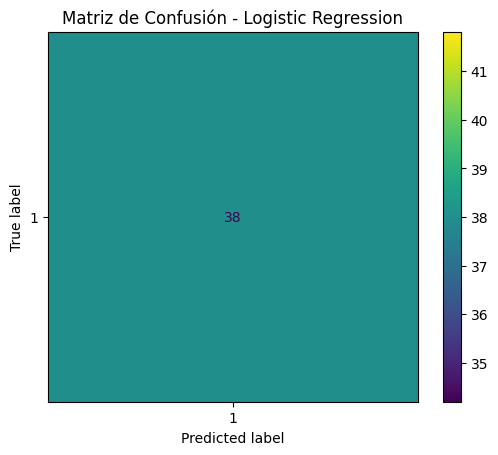


🔍 Random Forest - Evaluation on Original Test Set
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.82      0.90        38

    accuracy                           0.82        38
   macro avg       0.50      0.41      0.45        38
weighted avg       1.00      0.82      0.90        38



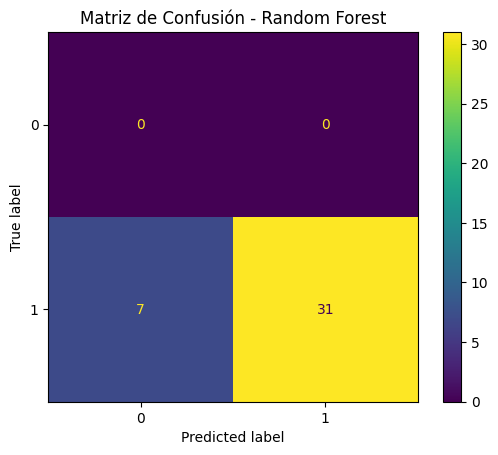


🔍 Decision Tree - Evaluation on Original Test Set
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.82      0.90        38

    accuracy                           0.82        38
   macro avg       0.50      0.41      0.45        38
weighted avg       1.00      0.82      0.90        38



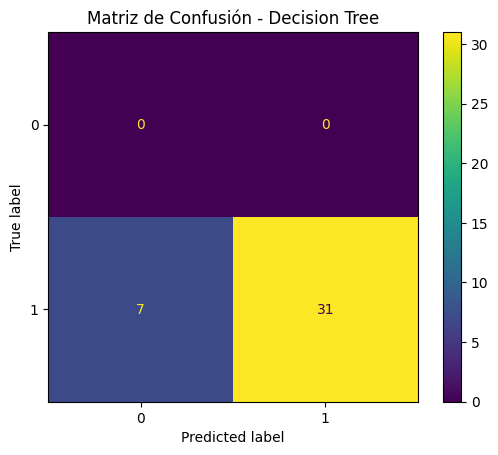


🔍 SVM - Evaluation on Original Test Set
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.79      0.88        38

    accuracy                           0.79        38
   macro avg       0.50      0.39      0.44        38
weighted avg       1.00      0.79      0.88        38



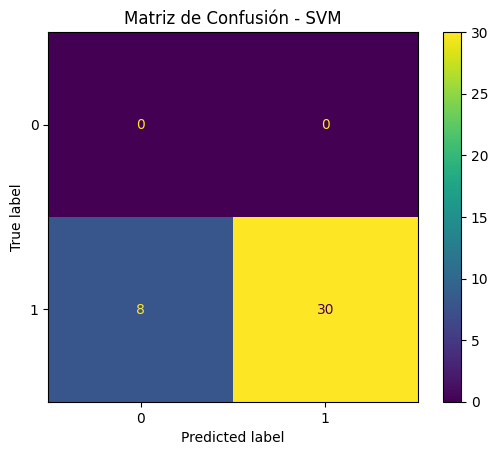

In [15]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Reentrenar modelos con los datos rebalanceados y evaluar en el set original de prueba
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)

    print(f"\n🔍 {name} - Evaluation on Original Test Set")
    print(classification_report(y_test, y_pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Matriz de Confusión - {name}")
    plt.grid(False)
    plt.show()


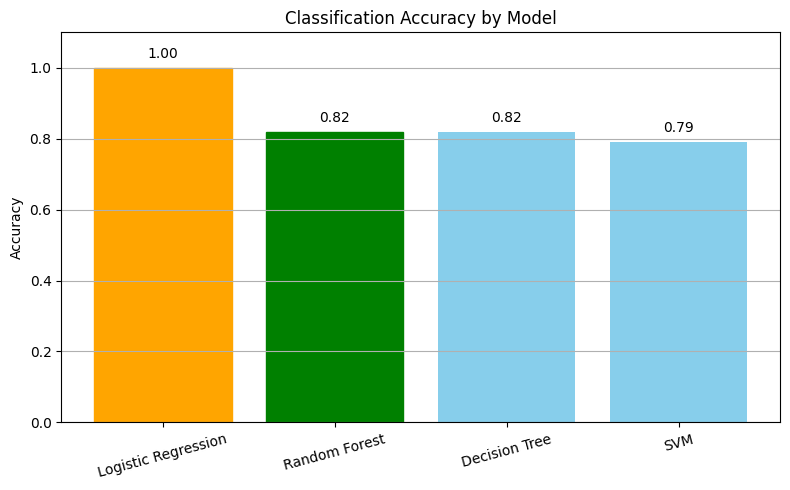

In [16]:
import matplotlib.pyplot as plt

# Classification accuracy values
accuracies = {
    'Logistic Regression': 1.00,
    'Random Forest': 0.82,
    'Decision Tree': 0.82,
    'SVM': 0.79
}

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')

# Highlight Logistic Regression (visually highest, but not reliable)
bars[0].set_color('orange')  # Logistic Regression
bars[1].set_color('green')   # Random Forest as best real-world performer

# Add text on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", 
             ha='center', va='bottom', fontsize=10)

# Customize chart
plt.title("Classification Accuracy by Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()

plt.show()
